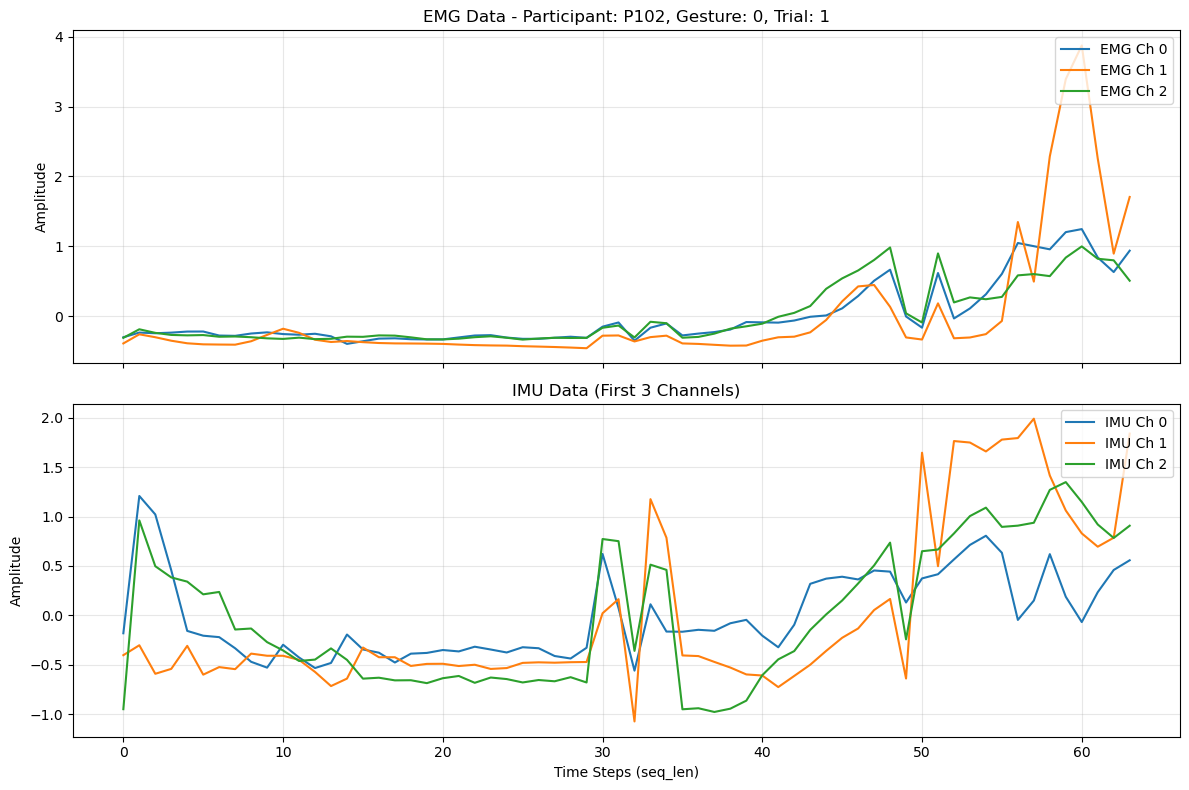

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your data
PATH_TO_YOUR_DATA = "C:\\Users\\kdmen\\Repos\\pers-gest-cls\\dataset\\segfilt_rts_tensor_dict.pkl" 

with open(PATH_TO_YOUR_DATA, 'rb') as f:
    full_dict = pickle.load(f)
    # Based on your script: tensor_dict = full_dict['data']
    tensor_dict = full_dict['data']

# 2. Pick your targets
pid = "P102"          # Example Participant
gesture_id = 0       # Example Gesture (0-indexed)
trial_idx = 0        # First trial (0-9)

# 3. Extract the data
# Shapes are (num_trials, seq_len, num_channels)
emg_data = tensor_dict[pid][gesture_id]['emg'][trial_idx]
imu_data = tensor_dict[pid][gesture_id].get('imu')[trial_idx]

# 4. Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 3 channels of EMG
for i in range(3):
    axes[0].plot(emg_data[:, i], label=f'EMG Ch {i}')
axes[0].set_title(f"EMG Data - Participant: {pid}, Gesture: {gesture_id}, Trial: {trial_idx+1}")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 3 channels of IMU
if imu_data is not None:
    for i in range(3):
        axes[1].plot(imu_data[:, i], label=f'IMU Ch {i}')
    axes[1].set_title(f"IMU Data (First 3 Channels)")
    axes[1].set_ylabel("Amplitude")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No IMU data found for this entry", ha='center')

axes[1].set_xlabel("Time Steps (seq_len)")

plt.tight_layout()
plt.show()